# Import Necessary Libraries

In [ ]:
import os 
from pathlib import Path 
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
from ultralytics import YOLO

# Prepare Data To Be in Ymal Format 

In [2]:
def create_yolo_yaml():
    base_path = r"C:\Users\MINA\Downloads\Drone Data Set\drone_dataset"
    
    yaml_content = f"""# YOLO Dataset Configuration
path: {base_path}
train: train/images
val: valid/images

# Number of classes
nc: 1

# Class names
names: ['drone']
"""
    
    yaml_path = Path(base_path) / "data.yaml"
    with open(yaml_path, 'w', encoding='utf-8') as f:
        f.write(yaml_content)
    
    print(f"Done : {yaml_path}")
    print("\nYAML Content:\n")
    print(yaml_content)

create_yolo_yaml()

Done : C:\Users\MINA\Downloads\Drone Data Set\drone_dataset\data.yaml

YAML Content:

# YOLO Dataset Configuration
path: C:\Users\MINA\Downloads\Drone Data Set\drone_dataset
train: train/images
val: valid/images

# Number of classes
nc: 1

# Class names
names: ['drone']



# Show Sample Of Data 

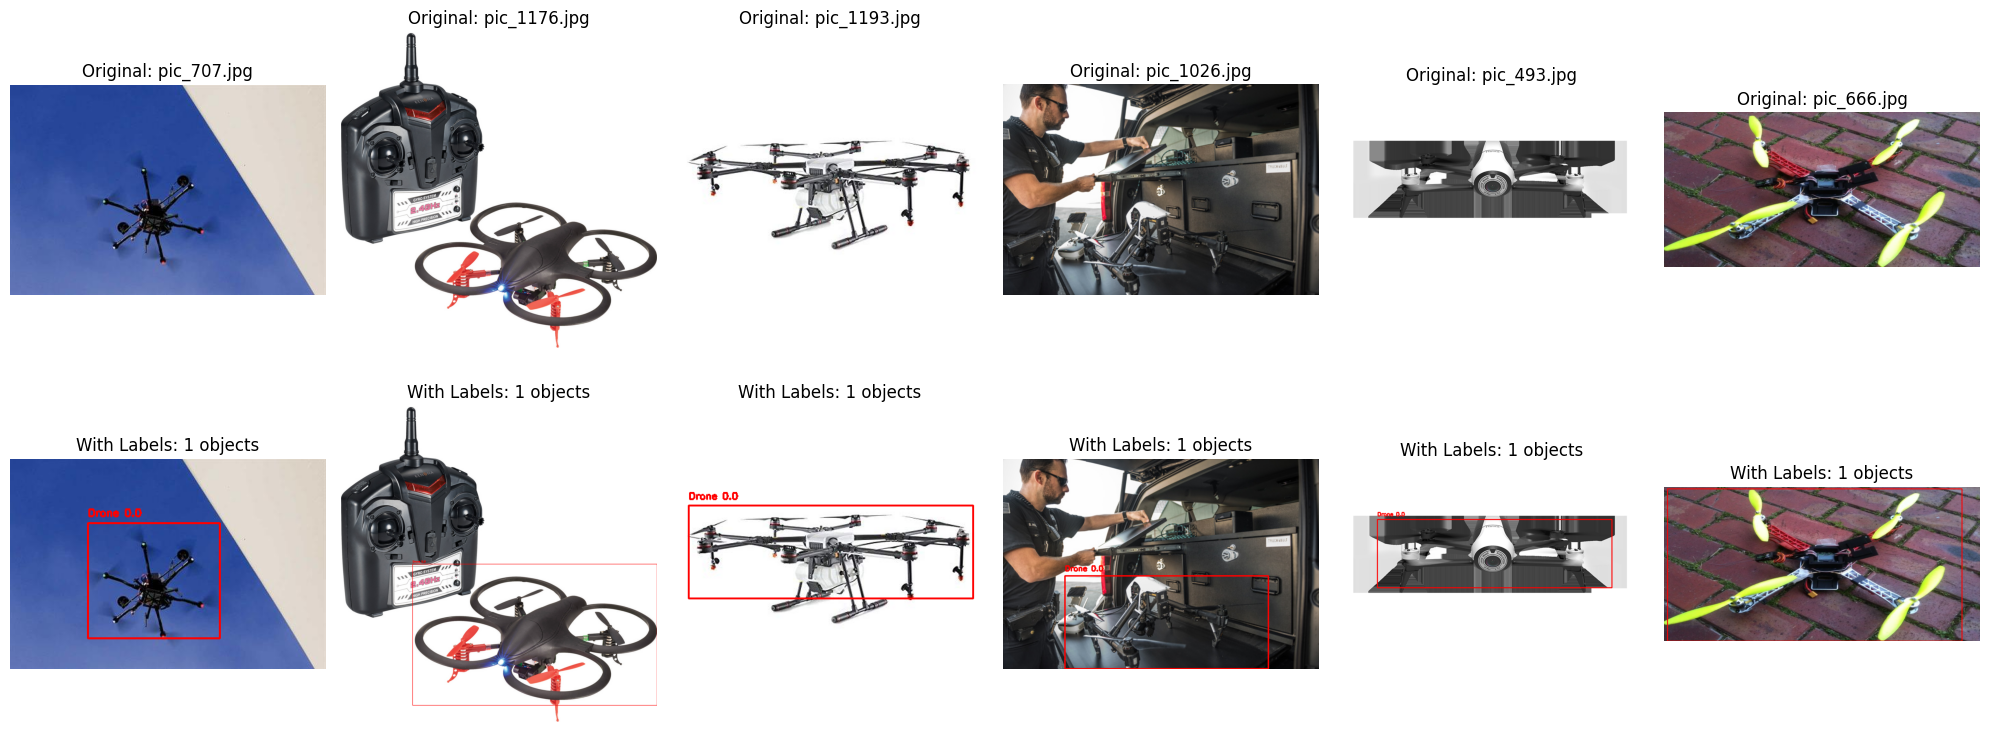

In [ ]:


def show_data_samples(num_samples=5):
    base_path = Path(r"C:\Users\MINA\Downloads\Drone Data Set\drone_dataset")
    train_images_path = base_path / "train" / "images"
    train_labels_path = base_path / "train" / "labels"
    image_files = list(train_images_path.glob("*.jpg")) + list(train_images_path.glob("*.png"))
    samples = random.sample(image_files, min(num_samples, len(image_files)))
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 8))
    if num_samples == 1:
        axes = axes.reshape(2, 1)
    
    for i, image_path in enumerate(samples):
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        label_path = train_labels_path / f"{image_path.stem}.txt"
        
        image_with_boxes = image.copy()
        h, w = image.shape[:2]
        
        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = f.readlines()
            
            for line in lines:
                data = line.strip().split()
                if len(data) == 5:
                    class_id, x_center, y_center, bbox_w, bbox_h = map(float, data)
                    
                    x_center *= w
                    y_center *= h
                    bbox_w *= w
                    bbox_h *= h
                    
                    x1 = int(x_center - bbox_w/2)
                    y1 = int(y_center - bbox_h/2)
                    x2 = int(x_center + bbox_w/2)
                    y2 = int(y_center + bbox_h/2)
                    
                    cv2.rectangle(image_with_boxes, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(image_with_boxes, f'Drone {class_id}', (x1, y1-10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        
        axes[0, i].imshow(image)
        axes[0, i].set_title(f'Original: {image_path.name}')
        axes[0, i].axis('off')
        axes[1, i].imshow(image_with_boxes)
        axes[1, i].set_title(f'With Labels: {len(lines) if label_path.exists() else 0} objects')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

show_data_samples(6)

# Train By YOLO V12


In [3]:
model = YOLO("yolo12n.pt")


In [7]:
import torch
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))
    print("current device:", torch.cuda.current_device())


cuda available: False


In [8]:
results = model.train(
    data=r"C:\Users\MINA\Downloads\Drone Data Set\drone_dataset\data.yaml",
    epochs=20,
    imgsz=416,
    batch=2,
    device='cpu'
)

New https://pypi.org/project/ultralytics/8.3.225 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.223  Python-3.14.0 torch-2.9.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\MINA\Downloads\Drone Data Set\drone_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=Fals